In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

---
## 데이터 세팅 (reverse.ipynb & reverse_test_init_dist.ipynb 동일)

In [2]:
rng = np.random.default_rng(42)

# ── Heart dataset ─────────────────────────────────────────────────────────────
heart_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
heart_means = np.column_stack([
    16 * np.sin(heart_t) ** 3,
    13 * np.cos(heart_t) - 5 * np.cos(2 * heart_t)
    - 2 * np.cos(3 * heart_t) - np.cos(4 * heart_t),
]) / 10  # (20, 2)

heart_std = 0.07
heart_x0 = np.vstack([
    mu + rng.standard_normal((80, 2)) * heart_std for mu in heart_means
])  # (1600, 2)

# ── Noise schedule ────────────────────────────────────────────────────────────
T = 500

def beta_fn(t):
    t = np.clip(t, 0, T - 1)
    return 1e-4 + (0.02 - 1e-4) * t / (T - 1)

def alpha_bar_fn(t):
    t = np.clip(t, 0, T - 1)
    a = 1e-4; b = (0.02 - 1e-4) / (T - 1)
    return np.exp(-(a * t + 0.5 * b * t**2))

def sigma2_fn(t):
    return 1.0 - alpha_bar_fn(t)

# ── GMM exact score ───────────────────────────────────────────────────────────
def gmm_score(x, t, means=heart_means, var=heart_std**2):
    ab    = alpha_bar_fn(t)
    s2    = sigma2_fn(t)
    mu_t  = np.sqrt(ab) * means
    var_t = ab * var + s2
    diff  = x[:, None, :] - mu_t[None, :, :]
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk); wk /= wk.sum(1, keepdims=True)
    return (wk[:, :, None] * (-diff / var_t)).sum(1)

heart_score = partial(gmm_score, means=heart_means, var=heart_std**2)

# ── Forward SDE ───────────────────────────────────────────────────────────────
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i in range(T):
        b = beta_fn(i)
        x = x * (1 - 0.5 * b) + np.sqrt(b) * rng.standard_normal(x.shape)
        saved[i + 1] = x.copy()
    return saved

heart_forward = forward_sde(heart_x0)

# ── Euler-Maruyama reverse (matches reverse_test_init_dist.ipynb exactly) ─────
# Reverse SDE: dx = [-β/2·x - β·s] dt + sqrt(β) dW  (dt < 0 going T→0)
def reverse_em(x_T, score_fn):
    x = x_T.copy()
    dt = -1  # stepping backwards: t decreases by 1 each step
    for t in range(T, 0, -1):
        b = beta_fn(t)
        s = score_fn(x, t)
        x = x + b * (-0.5 * x - s) * dt + np.sqrt(b) * rng.standard_normal(x.shape)
    return x

# ── Initial distributions ─────────────────────────────────────────────────────
N = len(heart_x0)
initials = {
    "heart_forward_xT":      heart_forward[T].copy(),
    "normal_var_0.5":        rng.normal(0.0, np.sqrt(0.5), (N, 2)),
    "wide_normal_var_5":     rng.normal(0.0, np.sqrt(5.0), (N, 2)),
    "shifted_normal_mean_3": rng.normal(3.0, 1.0, (N, 2)),
    "uniform_square":        rng.uniform(-3.0, 3.0, (N, 2)),
    "extreme_offset":        rng.normal(5.0, 3.0, (N, 2)),
}

restored = {name: reverse_em(x_T, heart_score) for name, x_T in initials.items()}
print("Done. keys:", list(restored.keys()))

Done. keys: ['heart_forward_xT', 'normal_var_0.5', 'wide_normal_var_5', 'shifted_normal_mean_3', 'uniform_square', 'extreme_offset']


# 복원 품질 지표: MMD² & Mode Entropy

복원된 샘플 $\hat{x}_0$과 원본 데이터 $x_0$을 비교

---

## 1. MMD² — 분포 기준



### 개념

커널 특징 공간에서 두 분포의 차이를 측정 — 1-대-1 매칭 불필요.
위치 오프셋, 형태 왜곡 등 분포 전체의 불일치를 하나의 스칼라로 표현.

### 공식

$$
\text{MMD}^2(P, Q) = \mathbb{E}_{x,x' \sim P}[k(x,x')] - 2\,\mathbb{E}_{x \sim P,\, y \sim Q}[k(x,y)] + \mathbb{E}_{y,y' \sim Q}[k(y,y')]
$$

비편향 샘플 추정:

$$
\widehat{\text{MMD}}^2 = \frac{1}{N(N-1)}\sum_{i \neq j} k(x_i, x_j)
\;-\; \frac{2}{NM}\sum_{i,j} k(x_i, y_j)
\;+\; \frac{1}{M(M-1)}\sum_{i \neq j} k(y_i, y_j)
$$

### 커널 — Multi-scale RBF

$$
k(x, y) = \sum_{l} \exp\!\left(-\frac{\|x-y\|^2}{2\sigma_l^2}\right)
$$

- $x$끼리의 유사도 → $x$ 분포가 얼마나 뭉쳐있는가
- $y$끼리의 유사도 → $y$ 분포가 얼마나 뭉쳐있는가
- $x-y$ 교차 유사도 → 두 분포가 얼마나 겹치는가 

두 분포가 같다면 "$x$끼리 뭉친 정도" 와 "$x-y$가 겹치는 정도" 가 같아야 하므로 상쇄되어 0  
두 분포가 완전히 분리되어 있으면 x끼리는 가깝고 x-y는 멀어서 교차항이 작아지고 MMD²가 커짐  

단일 $\sigma$는 포화(saturation) 문제:
- 너무 작음 → 거리가 조금만 멀어도 $K_{xy} \approx 0$ → 모든 케이스가 최대치
- 너무 큼 → 세 항이 모두 비슷 → 모든 케이스가 0에 가까움

$[\sigma/4,\, \sigma/2,\, \sigma,\, 2\sigma,\, 4\sigma]$ 5개 스케일을 합산해 포화 없이 위치 차이와 형태 차이를 동시에 포착.
$\sigma$는 $x$와 $y$를 합친 pairwise 거리의 median heuristic으로 자동 결정.

---

In [3]:
def pairwise_sq_euclidean(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """유클리드 거리의 제곱값: ||a[i] - b[j]||² for all (i, j) 
    Shape: (len(a), len(b))"""
    # ||a - b||² = ||a||² + ||b||² - 2 a·b^T
    sq_a = (a ** 2).sum(axis=1, keepdims=True)   # (N, 1)
    sq_b = (b ** 2).sum(axis=1, keepdims=True).T  # (1, M)
    return sq_a + sq_b - 2 * (a @ b.T)


def pairwise_euclidean(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """유클리드 거리: ||a[i] - b[j]|| for all (i, j) 
    Shape: (len(a), len(b))"""
    return np.sqrt(pairwise_sq_euclidean(a, b))


def mmd_squared(x: np.ndarray, y: np.ndarray, sigmas=None) -> float:
    """
    x: 실제 데이터(정답), y: 모델이 생성한 샘플
    Unbiased MMD² with multi-scale RBF kernel: k(x,y) = sum_l exp(-||x-y||²/2σ_l²)
    sigmas: None → [σ/4, σ/2, σ, 2σ, 4σ] where σ = median heuristic on pooled x, y
    """
    if sigmas is None:
        xy = np.vstack([x, y])
        pairwise = pairwise_euclidean(xy, xy)  # 대각성분(자기 자신) 값=0, 대칭행렬
        # 대각성분 위 원소들의 인덱스(상삼각 부분): (i,j)거리 = (j,i)거리
        idx = np.triu_indices(len(xy), k=1)    
        base = float(np.median(pairwise[idx])) # 데이터들 사이의 거리 중간값 
        sigmas = [base / 4, base / 2, base, base * 2, base * 4]

    sq_xx = pairwise_sq_euclidean(x, x)
    sq_yy = pairwise_sq_euclidean(y, y)
    sq_xy = pairwise_sq_euclidean(x, y)

    Kxx = np.zeros_like(sq_xx)
    Kyy = np.zeros_like(sq_yy)
    Kxy = np.zeros_like(sq_xy)
    for s in sigmas:
        g = 1.0 / (2 * s**2)  # 1/2σ²
        Kxx += np.exp(-g * sq_xx)
        Kyy += np.exp(-g * sq_yy)
        Kxy += np.exp(-g * sq_xy)

    N, M = len(x), len(y)
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)
    # 대각 제외한 평균
    return float(Kxx.sum() / (N * (N - 1)) - 2 * Kxy.mean() + Kyy.sum() / (M * (M - 1)))

## 2. Mode Entropy — 구조 기준



### 개념

하트 GMM은 중심점 20개 $\{\mu_k\}$가 명시적으로 주어지므로, 복원 샘플을 nearest-mode로 할당해 **모드별 밀도 불균등**을 직접 측정

MMD²는 분포 전체의 차이를 잡지만, "어느 방향으로 점이 몰렸는가"는 포착하지 못함 → 이를 엔트로피로 보완

### 할당

$$a_i = \arg\min_k \|\hat{x}_i - \mu_k\|$$

radius 제한 없이 모든 점을 가장 가까운 모드에 할당.

### Normalized Entropy

$$H_{\text{norm}} = \frac{-\sum_{k=1}^{K} p_k \log p_k}{\log K}, \qquad p_k = \frac{n_k}{\sum_j n_j}$$

- 1.0 = 모든 모드에 균등 분포 (완벽한 복원)
- 낮을수록 특정 모드에 집중 → 시작 분포 편향의 잔재

### 히트맵

모드별 카운트를 직접 시각화해 "어느 모드가 과잉/결핍인지" 확인.

In [4]:
def mode_entropy(x_restored, means):
    """
    Normalized entropy of per-mode sample counts (no radius cutoff).
    모든 점을 nearest-mode에 할당 후 카운트 분포의 엔트로피

    반환: (entropy_norm, counts)
    """
    K = len(means)  # means: (20,2) -> 클러스터 수 = 20
    # 거리의 최솟값에 해당하는 인덱스 번호(클러스터) 반환
    # (1600,2) + (20,2) -> (1600,20) -argmin(axis=1)-> (1600,1)
    nearest = pairwise_euclidean(x_restored, means).argmin(axis=1)
    # 각 클러스터 번호(0~19)가 얼마나 나왔는지 count, minlength: counts의 최소 길이
    counts = np.bincount(nearest, minlength=K)
    pk = counts / counts.sum()  # 비율로 변환
    pk_nz = pk[pk > 0]  # 0인 원소 제거: log0 방지
    return float(-np.sum(pk_nz * np.log(pk_nz)) / np.log(K)), counts

def support_rmse(x, support):
    dist2 = ((x[:, None, :] - support[None, :, :]) ** 2).sum(axis=-1)
    min_dist2 = dist2.min(axis=1)
    return np.sqrt(min_dist2.mean())

---
## 결과

In [5]:
results = {}
ref = heart_x0
support = heart_means

for name, x_hat in restored.items():
    H, counts = mode_entropy(x_hat, heart_means)
    mmd2 = mmd_squared(x_hat, ref)
    rmse = support_rmse(x_hat, support)

    results[name] = {
        "MMD2": mmd2,
        "Entropy_norm": H,
        "Support_RMSE": rmse,
        "_counts": counts,
    }

hdr = f"{'Init distribution':<28} {'MMD2':>10} {'Entropy_norm':>13} {'Support_RMSE':>15}"
print(hdr)
print("-" * len(hdr))

for name, m in results.items():
    print(
        f"{name:<28} "
        f"{m['MMD2']:>10.5f} "
        f"{m['Entropy_norm']:>13.4f} "
        f"{m['Support_RMSE']:>15.6f}"
    )

C:\Users\SEC\AppData\Local\Temp\ipykernel_14792\3066821599.py:13: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(pairwise_sq_euclidean(a, b))


Init distribution                  MMD2  Entropy_norm    Support_RMSE
---------------------------------------------------------------------
heart_forward_xT               -0.00101        0.9984        0.098593
normal_var_0.5                 -0.00145        0.9972        0.096371
wide_normal_var_5              -0.00081        0.9975        0.096336
shifted_normal_mean_3           0.04892        0.9826        0.096551
uniform_square                 -0.00031        0.9971        0.096001
extreme_offset                  0.15190        0.9513        0.095760


---
## 시각화

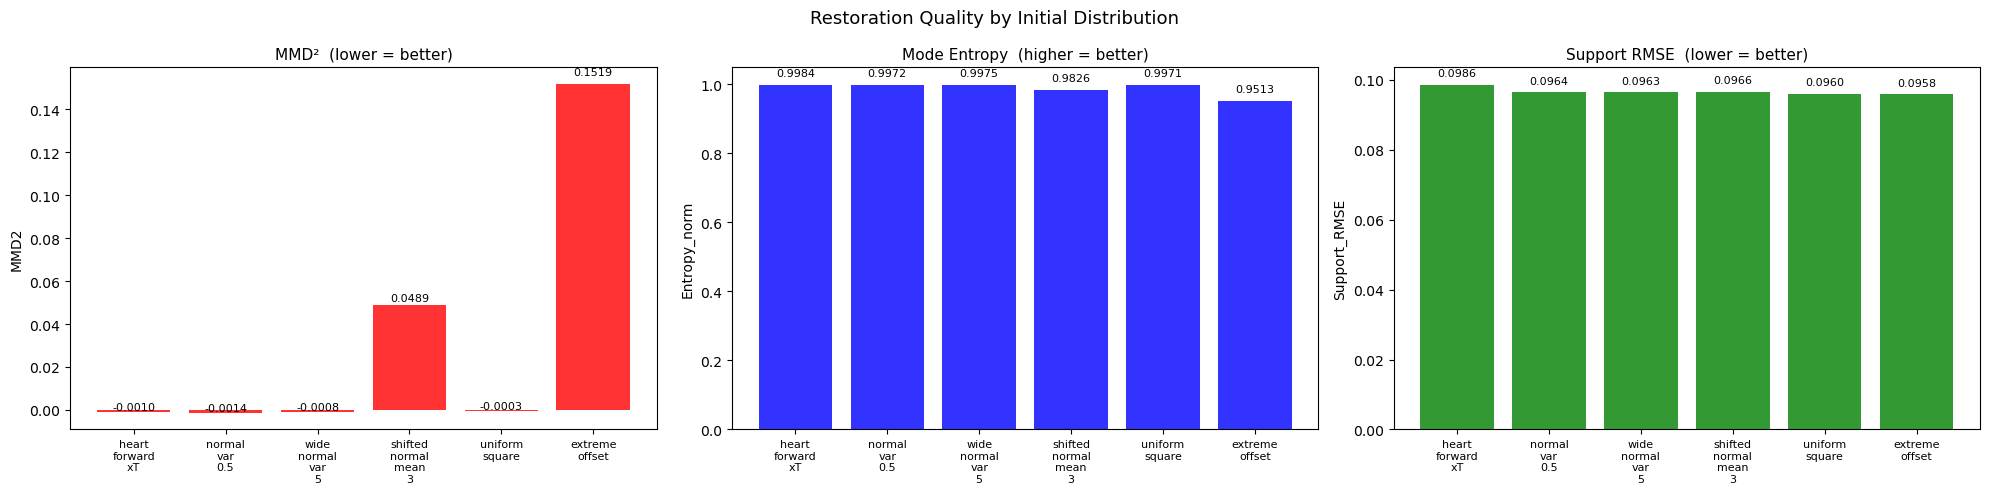

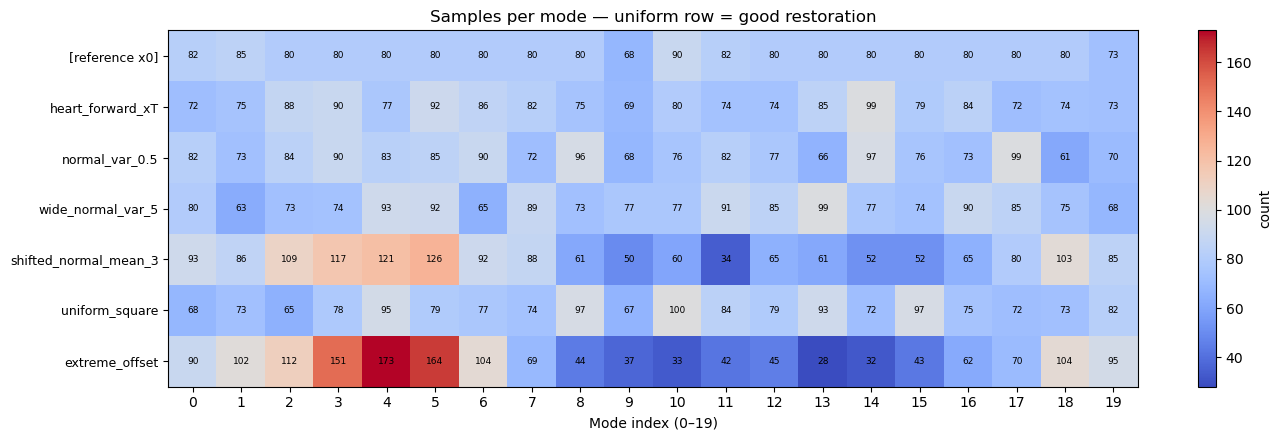

In [6]:
names  = list(results.keys())  # 분포 이름
x_pos  = np.arange(len(names))  # 막대 위치: [0,1,2,...,5]
labels = [n.replace("_", "\n") for n in names]  # _를 줄바꿈으로 변환

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric, title, color in zip(
    axes,
    ["MMD2", "Entropy_norm", "Support_RMSE"],
    [
        "MMD²  (lower = better)",
        "Mode Entropy  (higher = better)",
        "Support RMSE  (lower = better)",
    ],
    ["red", "blue", "green"],
):
    vals = [results[n][metric] for n in names]  # 현재 metric 값
    bars = ax.bar(x_pos, vals, color=color, alpha=0.8) # 막대그래프
    ax.set_xticks(x_pos)  # x축 눈금
    ax.set_xticklabels(labels, fontsize=8) # x축 레이블 이름
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric)  # y축 값

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, # 막대 중앙
                bar.get_height() * 1.02, # 막대 꼭대기 * 1.02 높이
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Restoration Quality by Initial Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# ── 히트맵 ────────────────────────────────────────────────────
_, ref_counts = mode_entropy(heart_x0, heart_means)
rest_matrix = np.stack([results[n]["_counts"] for n in names], axis=0)

count_matrix = np.vstack([ref_counts[np.newaxis, :], rest_matrix])  # (7, 20)
row_labels = ["[reference x0]"] + names

plt.figure(figsize=(14, 4.5))
im = plt.imshow(count_matrix, aspect="auto", cmap="coolwarm")
plt.xticks(range(len(heart_means)))
plt.xlabel("Mode index (0–19)")
plt.yticks(range(len(row_labels)), row_labels, fontsize=9)
plt.title("Samples per mode — uniform row = good restoration")

for i in range(len(row_labels)):
    for j in range(len(heart_means)):
        plt.text(j, i, str(count_matrix[i, j]), ha="center", va="center", fontsize=6.5)
plt.colorbar(im, label="count")
plt.tight_layout()
plt.show()

---
## 해석 1 — 초기 분포 차이에 따른 복원 품질

### MMD² 결과

`heart_forward_xT`, `normal_var_0.5`, `wide_normal_var_5`, `uniform_square`는 MMD²가 거의 0에 가깝고, `shifted_normal_mean_3`과 `extreme_offset`은 눈에 띄게 크다.

가설: $x_T$가 forward process의 최종 분포 $p_T \approx \mathcal{N}(0, I)$에서 왔다고 가정한다. 따라서 분산이 다르거나 위치가 치우친 초기 분포를 넣으면 이 가정이 깨지고, score $s(x,t)$가 해당 영역을 제대로 커버하지 못해 복원이 틀어질 것이다.

- **`normal_var_0.5`, `wide_normal_var_5`**: 중심은 맞지만 분산이 다름 → 분산 차이는 reverse 과정에서 어느 정도 보정되어 결과가 양호
- **`uniform_square`**: 균등 분포이지만 지지 범위가 $[-3, 3]$으로 $\mathcal{N}(0,I)$와 겹침 → 양호
- **`shifted_normal_mean_3`**: 평균이 3 이동 → score가 해당 위치를 거의 학습하지 못한 영역, 복원 품질 저하
- **`extreme_offset`**: 평균 5, 분산 9 → score가 사실상 0에 가까운 영역에서 시작, 복원 실패에 가까움

### Mode Entropy 결과

모든 케이스에서 Entropy_norm이 0.95 이상으로 높다. 이는 **복원에 성공한 샘플들은 20개 모드를 고르게 커버**한다는 뜻이다. 즉 reverse diffusion은 특정 모드에 collapse하지 않고, 초기 분포 편향의 영향이 분포 전체의 이동(MMD²)으로 나타나지 모드 불균형(Entropy)으로는 잘 나타나지 않는다.

`extreme_offset`만 Entropy가 0.95 아래로 떨어지는데, 이는 복원 자체가 실패해 일부 모드에 점이 몰리기 시작했음을 의미한다.

---
## Score 추정 방법 × Integrator 비교

In [7]:
def plot_steps(traj, steps=None, order="asc", color="#3498db", title=""):
    """스텝별 분포 시각화.

    order: "asc"  → t 오름차순 (forward, 0→T)
           "desc" → t 내림차순 (reverse, T→0)
    """
    if steps is None:
        steps = sorted(traj.keys())

    if order == "asc":
        steps = list(steps)
    elif order == "desc":
        steps = list(reversed(steps))
    else:
        raise ValueError(f"order must be 'asc' or 'desc', got {order!r}")

    ncols = int(len(steps) / 2)
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    for ax, t in zip(axes.flatten(), steps):
        pts = traj.get(t)
        if pts is not None:
            ax.scatter(*pts.T, s=4, alpha=0.35, c=color)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(f"t={t}")
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Forward SDE ───────────────────────────────────────────────────────────────
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i in range(T):
        b = beta_fn(i)
        x = x * (1 - 0.5 * b) + np.sqrt(b) * rng.standard_normal(x.shape)
        saved[i + 1] = x.copy()
    return saved


fwd = {}
for name, x0 in {"heart": heart_x0}.items():
    fwd[name] = forward_sde(x0)

SAVE_STEPS = [0, 100, 200, 300, 400, 500]

In [8]:
def reverse_em(x_T, t_arr, score_fn):
    traj = {t_arr[0]: x_T.copy()}
    x = x_T.copy()
    dt = -1
    for t in t_arr[1:]:
        b = beta_fn(t)
        s = score_fn(x, t)
        x = x + b * (-0.5 * x - s) * dt + np.sqrt(b) * rng.standard_normal(x.shape)
        traj[t] = x.copy()
    return traj


# Probability Flow ODE — 연속 t 사용
def PF_ODE(x, t, score_fn):
    b = beta_fn(t)
    s = score_fn(x, t)
    return -0.5 * b * x - 0.5 * b * s


# Euler Method
def euler_method(f, r, t, **kwargs):
    h = t[1] - t[0]
    for i in range(1, len(t)):
        r[i] = r[i - 1] + h * f(r[i - 1], t[i - 1], **kwargs)

    return r


# Predictor Corrector Method(PCM)
def PCM(f, r, t, **kwargs):
    h = t[1] - t[0]
    for i in range(1, len(t)):
        p = r[i - 1] + h * f(r[i - 1], t[i - 1], **kwargs)
        r[i] = r[i - 1] + h / 2 * (f(r[i - 1], t[i - 1], **kwargs) + f(p, t[i - 1], **kwargs))

    return r


# Runge-Kutta Method(RK) - RK2
def RK2(f, r, t, **kwargs):
    h = t[1] - t[0]
    for i in range(len(t) - 1):
        k1 = h * f(r[i], t[i], **kwargs)
        k2 = h * f(r[i] + 0.5 * k1, t[i] + 0.5 * h, **kwargs)
        r[i + 1] = r[i] + k2
    return r


# RK4
def ODE_MV_RK4(f, r, t, **kwargs):
    h = t[1] - t[0]
    k = np.zeros((4, *r.shape[1:]), float)
    for i in range(len(t) - 1):
        k[0] = h * f(r[i], t[i], **kwargs)
        k[1] = h * f(r[i] + k[0] / 2, t[i] + h / 2, **kwargs)
        k[2] = h * f(r[i] + k[1] / 2, t[i] + h / 2, **kwargs)
        k[3] = h * f(r[i] + k[2], t[i] + h, **kwargs)
        r[i + 1] = r[i] + (k[0] + 2 * k[1] + 2 * k[2] + k[3]) / 6
    return r


def reverse_euler(x_T, t_arr, score_fn):
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = euler_method(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[t] = r[i].copy()
    return traj


def reverse_PCM(x_T, t_arr, score_fn):
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = PCM(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[t] = r[i].copy()
    return traj


def reverse_rk(x_T, t_arr, score_fn):
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = RK2(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[t] = r[i].copy()
    return traj


def reverse_rk4(x_T, t_arr, score_fn):
    """Probability Flow ODE (deterministic), RK4 적분"""
    r = np.empty((len(t_arr), *x_T.shape))
    r[0] = x_T

    r = ODE_MV_RK4(PF_ODE, r, t_arr, score_fn=score_fn)

    traj = {}
    for i, t in enumerate(t_arr):
        traj[t] = r[i].copy()
    return traj

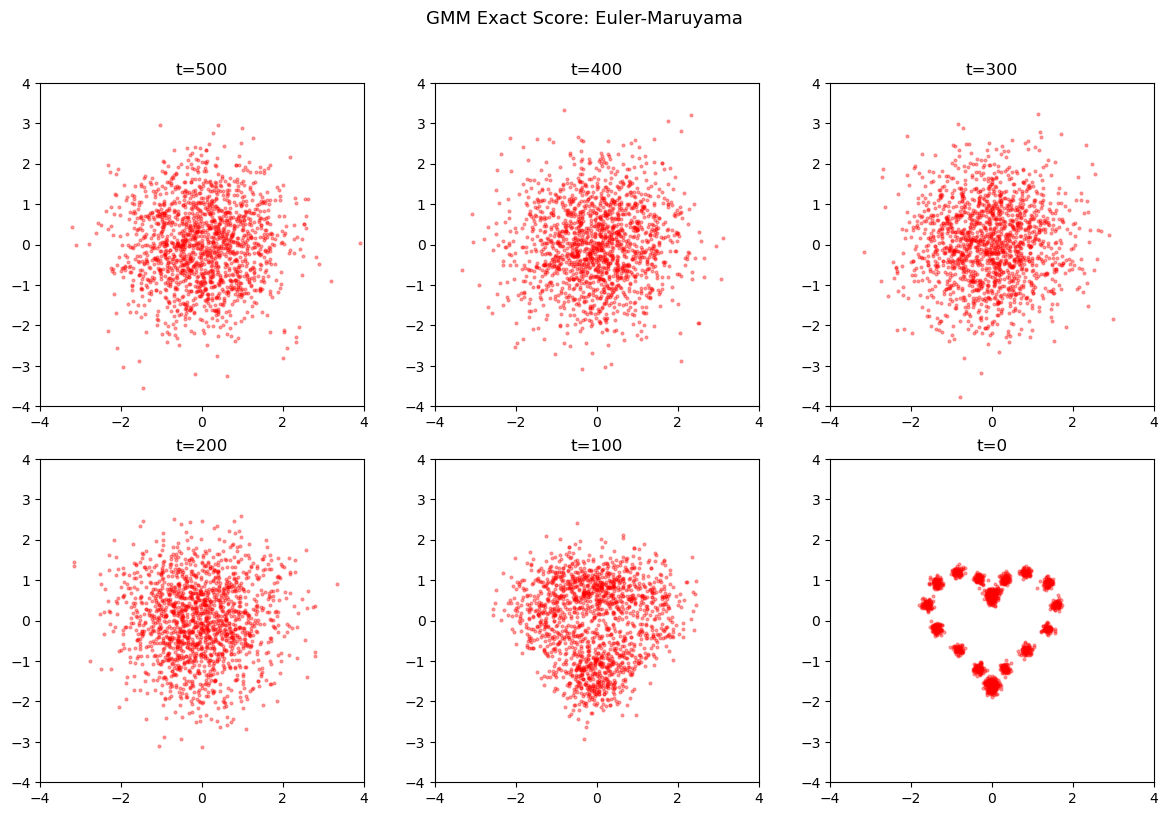

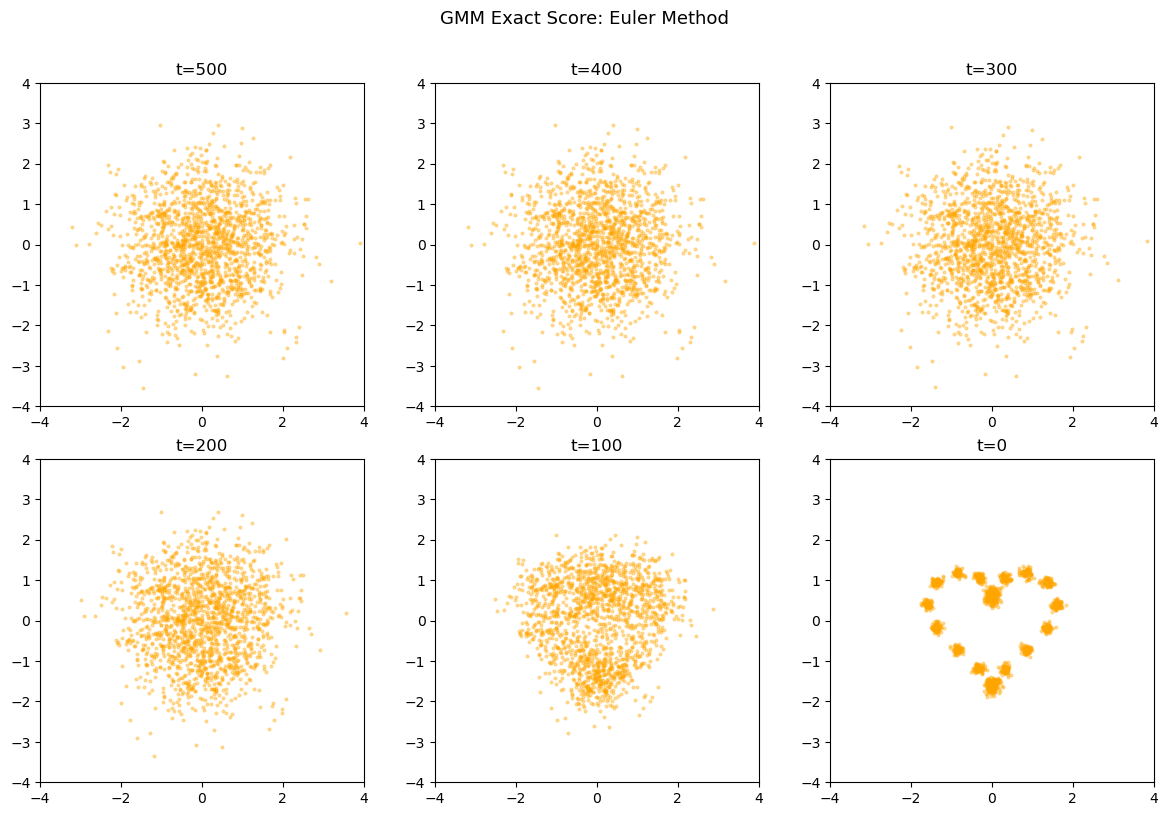

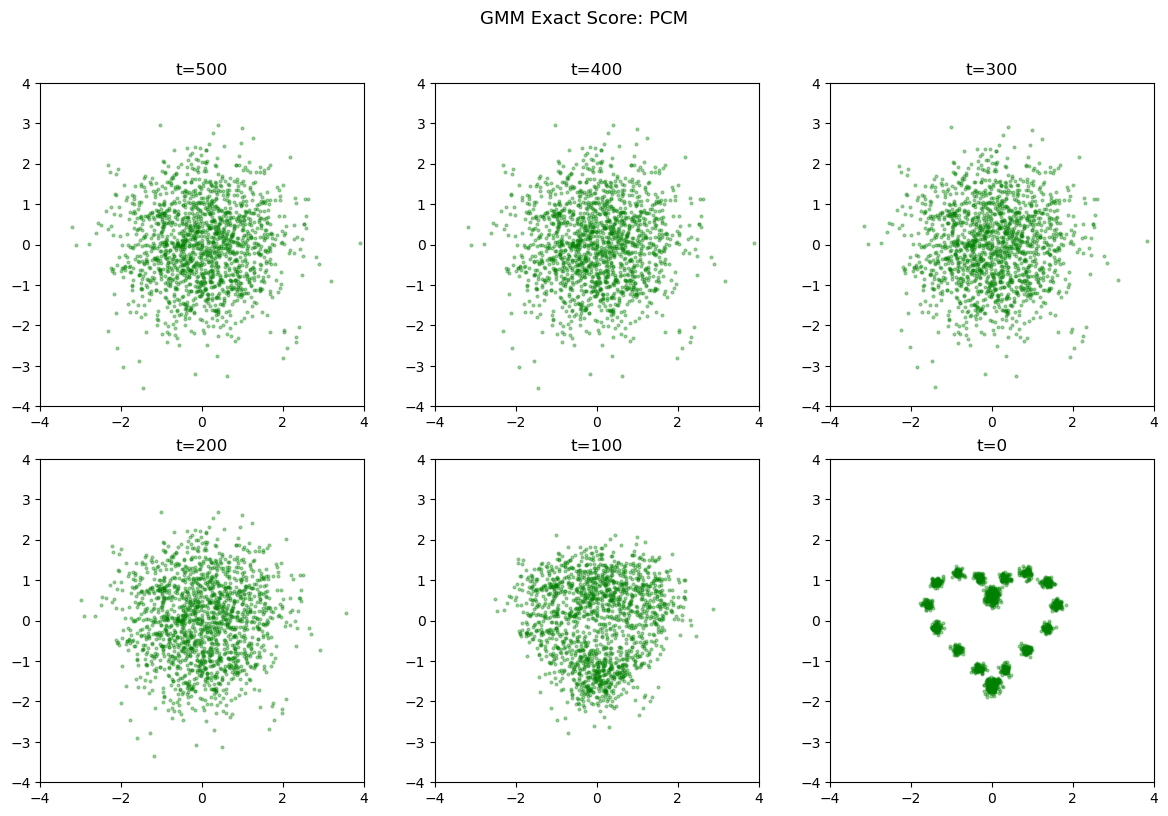

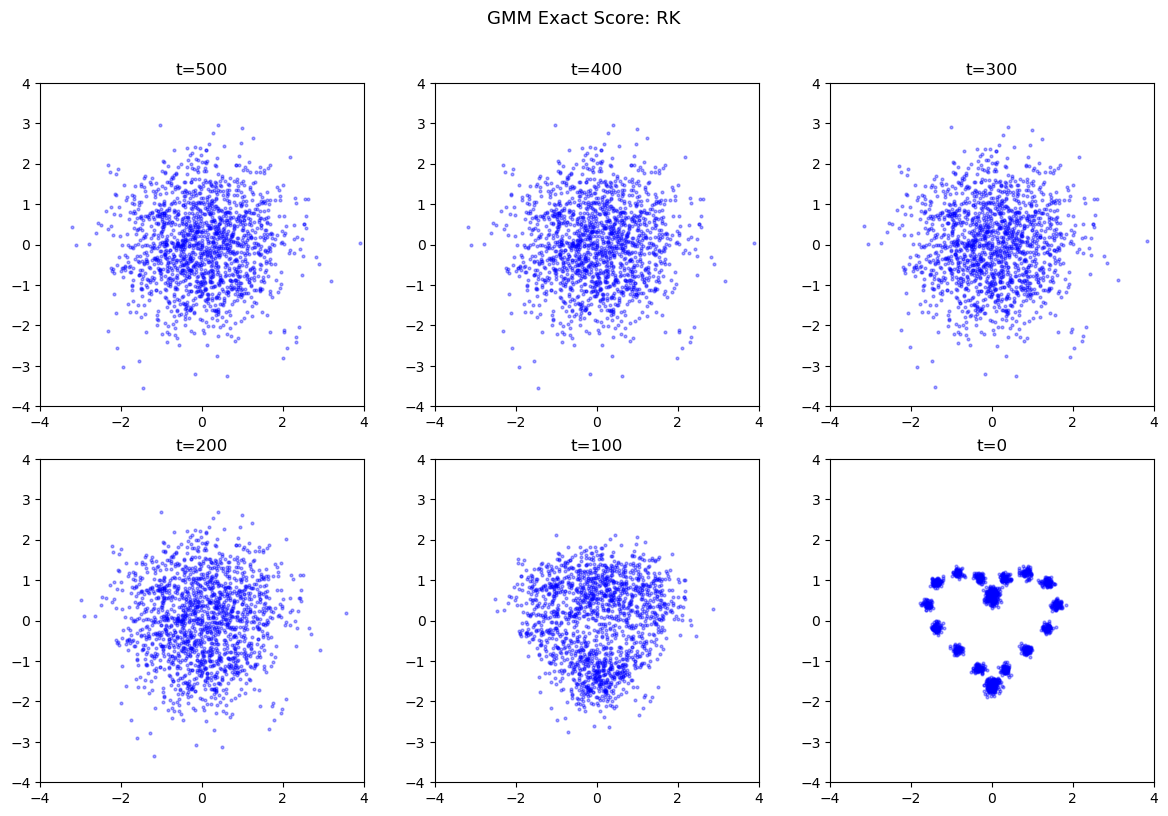

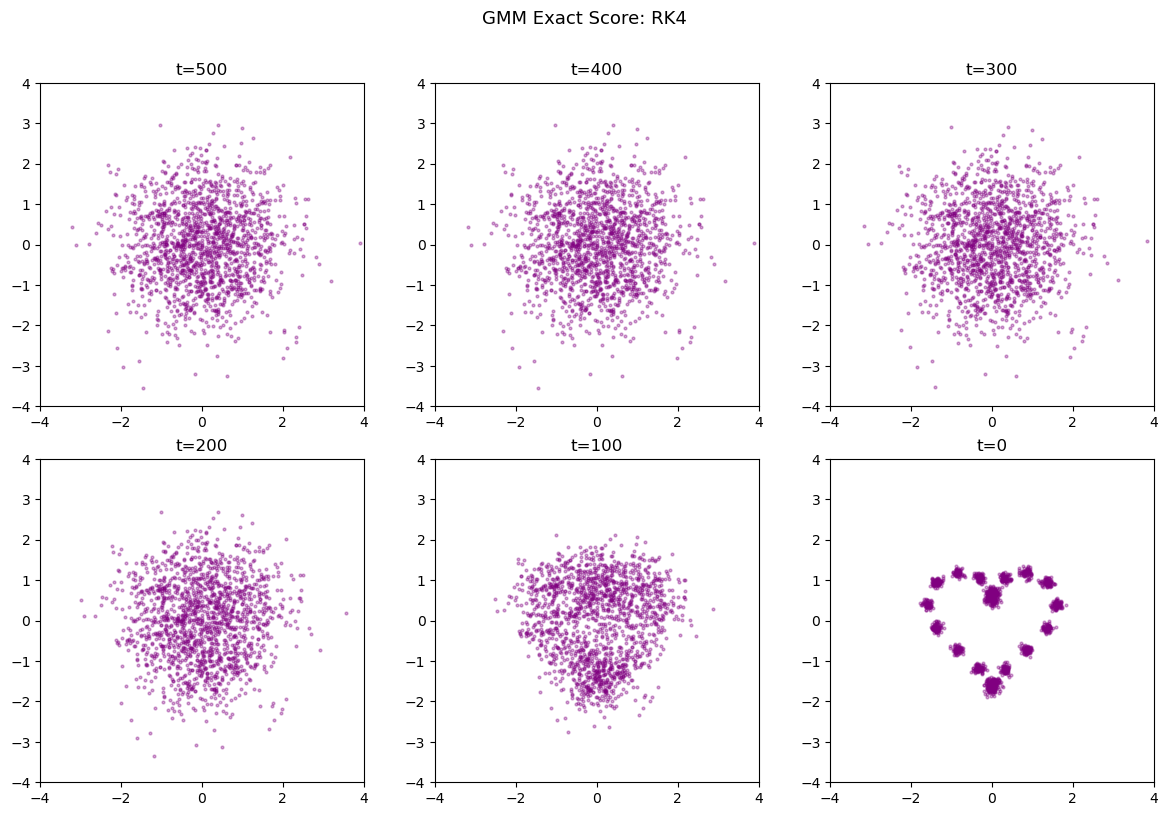

In [9]:
from functools import partial

def gmm_score(x, t, means, var):
    ab = alpha_bar_fn(t)
    s2 = sigma2_fn(t)
    mu_t = np.sqrt(ab) * means   # K개 2D Gaussian 중심점 배열: (K,2)
    var_t = ab * var + s2        # scalar: (K,2)

    # N개의 각 점에서 K개의 중심점까지의 차이벡터
    # x: (N,2) -> (N,1,2)
    # mu_t: (K,2) -> (1,K,2)
    # diff: (N,1,2) - (1,K,2) = (N,K,2) - broadcasting
    diff = x[:, None, :] - mu_t[None, :, :]

    # Gaussain 밀도 구하는 과정
    # .sum(-1)으로 마지막 축(좌표 2개)을 합산: (dx)^2 + (dy)^2 = ‖x−μ‖²
    # (N,K,2) -> (N,K)
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    # 최댓값 빼며 exp overflow 방지 - softmax 과정에서 상쇄
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    # softmax
    wk /= wk.sum(1, keepdims=True)  # (N,K) — 사후확률 w_k(x,t)

    score_k = -diff / var_t      # (N,K,2)
    return (wk[:, :, None] * score_k).sum(1)  # (N,2)


t_arr = np.arange(T, -1, -1)
heart_score = partial(gmm_score, means=heart_means, var=0.07**2)

x_T = fwd["heart"][T].copy()
traj_em = reverse_em(x_T, t_arr, heart_score)
traj_euler = reverse_euler(x_T, t_arr, heart_score)
traj_pcm = reverse_PCM(x_T, t_arr, heart_score)
traj_rk = reverse_rk(x_T, t_arr, heart_score)
traj_rk4 = reverse_rk4(x_T, t_arr, heart_score)

plot_steps(traj_em, steps=SAVE_STEPS, order="desc", color="red", title="GMM Exact Score: Euler-Maruyama")
plot_steps(traj_euler, steps=SAVE_STEPS, order="desc", color="orange", title="GMM Exact Score: Euler Method")
plot_steps(traj_pcm, steps=SAVE_STEPS, order="desc", color="green", title="GMM Exact Score: PCM")
plot_steps(traj_rk, steps=SAVE_STEPS, order="desc", color="blue", title="GMM Exact Score: RK")
plot_steps(traj_rk4, steps=SAVE_STEPS, order="desc", color="purple", title="GMM Exact Score: RK4")

---
## 복원 품질 지표: MMD² & Mode Entropy

In [10]:
ref = heart_x0
support = heart_means

case_results = {
    "EM":     traj_em[0],
    "Euler":  traj_euler[0],
    "PCM":    traj_pcm[0],
    "RK":     traj_rk[0],
    "RK4":    traj_rk4[0],
}

hdr = f"{'Integrator':<12} {'MMD2':>10} {'Entropy_norm':>13} {'Support_RMSE':>15}"
print(hdr)
print("-" * len(hdr))

metrics = {}

for name, x_hat in case_results.items():
    H, counts = mode_entropy(x_hat, heart_means)
    mmd2 = mmd_squared(x_hat, ref)
    rmse = support_rmse(x_hat, support)

    metrics[name] = {
        "MMD2": mmd2,
        "Entropy_norm": H,
        "Support_RMSE": rmse,
        "_counts": counts,
    }

    print(
        f"{name:<12} "
        f"{mmd2:>10.5f} "
        f"{H:>13.4f} "
        f"{rmse:>15.6f}"
    )

Integrator         MMD2  Entropy_norm    Support_RMSE
-----------------------------------------------------


C:\Users\SEC\AppData\Local\Temp\ipykernel_14792\3066821599.py:13: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(pairwise_sq_euclidean(a, b))


EM              0.00034        0.9978        0.094370
Euler          -0.00186        0.9974        0.093599
PCM            -0.00186        0.9973        0.094519
RK             -0.00186        0.9973        0.094011
RK4            -0.00186        0.9973        0.094000


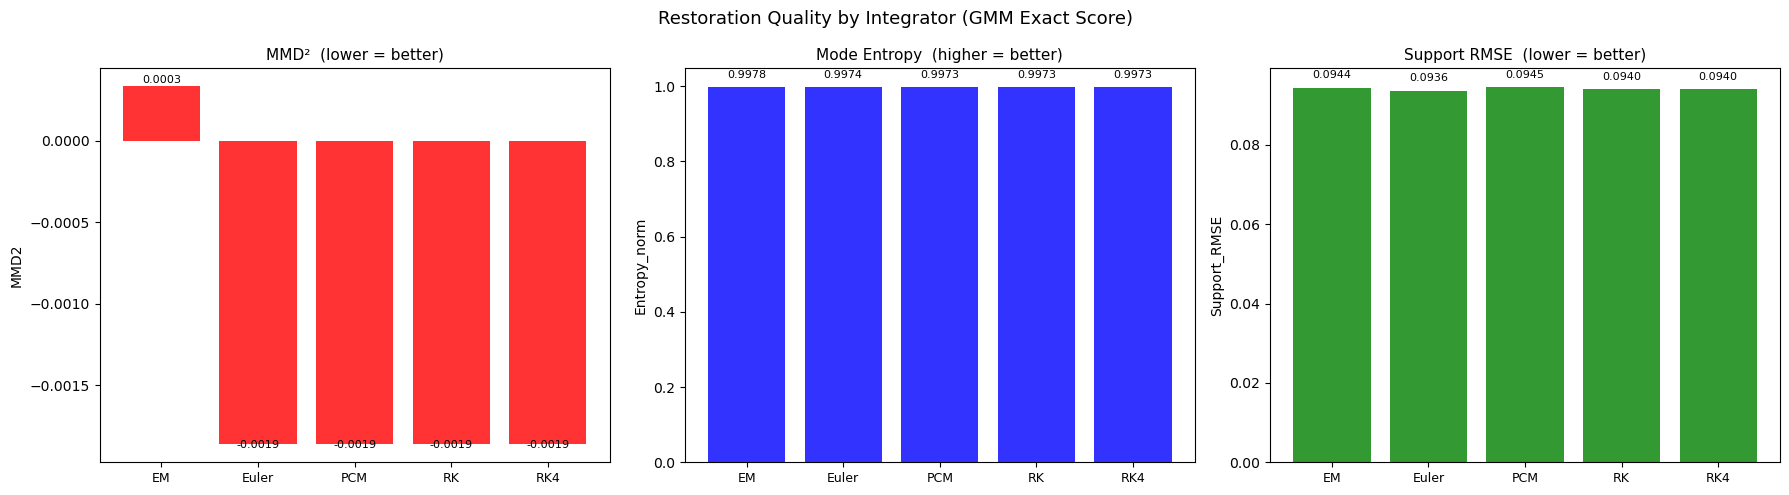

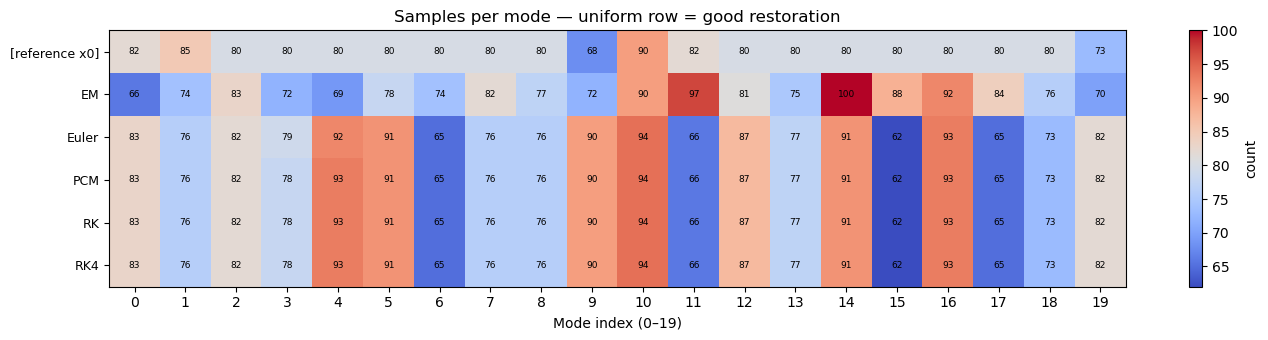

In [11]:
names  = list(metrics.keys())
x_pos  = np.arange(len(names))
labels = names

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title, color in zip(
    axes,
    ["MMD2", "Entropy_norm", "Support_RMSE"],
    [
        "MMD²  (lower = better)",
        "Mode Entropy  (higher = better)",
        "Support RMSE  (lower = better)",
    ],
    ["red", "blue", "green"],
):
    vals = [metrics[n][metric] for n in names]
    bars = ax.bar(x_pos, vals, color=color, alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Restoration Quality by Integrator (GMM Exact Score)", fontsize=13)
plt.tight_layout()
plt.show()

# ── 히트맵 ──────────────────────────────────────────────────────────────────
_, ref_counts = mode_entropy(heart_x0, heart_means)
rest_matrix = np.stack([metrics[n]["_counts"] for n in names], axis=0)

count_matrix = np.vstack([ref_counts[np.newaxis, :], rest_matrix])  # (6, 20)
row_labels = ["[reference x0]"] + names

plt.figure(figsize=(14, 3.5))
im = plt.imshow(count_matrix, aspect="auto", cmap="coolwarm")
plt.xticks(range(len(heart_means)))
plt.xlabel("Mode index (0–19)")
plt.yticks(range(len(row_labels)), row_labels, fontsize=9)
plt.title("Samples per mode — uniform row = good restoration")
for i in range(len(row_labels)):
    for j in range(len(heart_means)):
        plt.text(j, i, str(count_matrix[i, j]), ha="center", va="center", fontsize=6.5)
plt.colorbar(im, label="count")
plt.tight_layout()
plt.show()

---
## 해석 2 — SDE vs ODE solver에 따른 복원 품질

### ODE solver 4종이 동일한 이유

Euler, PCM, RK, RK4 모두 같은 Probability Flow ODE를 풀며, 결과가 사실상 동일하다.

$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)x - \frac{1}{2}\beta(t)s(x,t)$$

$\beta(t) \in [10^{-4},\, 0.02]$로 매우 작아서 drift 자체가 작다. Solver 간 차이는 고차 오차항인데, 오차항에는 drift의 변화율이 곱해지므로 $\beta$가 작으면 고차 항도 같이 작아진다. 결국 1차 근사인 Euler와 4차인 RK4가 실질적으로 동일한 결과를 낸다.

### Euler-Maruyama가 ODE보다 나쁜 이유

EM과 ODE는 $\beta$도 $\Delta t$도 동일하다. 이산화 오차 자체도 비슷하다. 차이는 오직 **노이즈 항** 하나다.

$$x_{t-1}^{\text{EM}} = x_t + \beta\!\left(-\tfrac{1}{2}x_t - s\right)\Delta t + \underbrace{\sqrt{\beta}\,\epsilon}_{\text{ODE에는 없음}}$$

$\sqrt{\beta} \approx \sqrt{0.02} \approx 0.14$인 노이즈가 500스텝 동안 독립적으로 더해진다. 누적 분산은 $\sum_t \beta_t \approx 500 \times 0.01 = 5$ 수준으로, 데이터 스케일 대비 무시할 수 없다. Score 추정이 완벽해도 이 노이즈가 샘플을 퍼뜨린다.

PF ODE는 노이즈 항이 없으므로 이 문제가 없다. Fokker-Planck 수준에서 SDE와 동일한 $p_t$를 유지하므로 이론적 정당성도 같다.

### 요약

| | EM | ODE (Euler/PCM/RK/RK4) |
|---|---|---|
| 이산화 오차 | EM·ODE 동일 ($\beta$ 작아 둘 다 무시 가능) | EM·ODE 동일 |
| 노이즈 | 매 스텝 $\sqrt{\beta}\,\epsilon$ 누적, 샘플 퍼짐 | 없음 |
| solver 간 차이 | — | drift가 작아 고차 항 차이 무시, 모두 동일 수렴 |


## 해석 3 — Support RMSE에 따른 좌표 기준 복원 품질

### Support RMSE 결과

Support RMSE는 복원된 샘플이 heart GMM의 중심점 20개에 얼마나 가까운지를 측정한다.

$$\mathrm{Support\ RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\min_k |\hat{x}_i-\mu_k|^2}$$

여기서 $\hat{x}_i$는 복원된 샘플이고, $\mu_k$는 heart GMM의 $k$번째 중심점이다. 즉 각 복원 샘플을 가장 가까운 mode 중심에 대응시킨 뒤, 그 거리의 평균적인 크기를 계산한다.

값이 작을수록 복원된 점들이 원래 heart 구조 근처에 잘 놓였다는 뜻이고, 값이 클수록 복원된 점들이 mode 중심에서 멀리 퍼졌다는 뜻이다.

### MMD², Mode Entropy와의 차이

MMD²는 원본 분포와 복원 분포의 전체적인 차이를 측정한다. 따라서 위치 오프셋이나 형태 왜곡은 잘 잡지만, 개별 샘플이 실제 mode 중심에서 얼마나 떨어져 있는지는 직접적으로 보여주지 않는다.

Mode Entropy는 복원 샘플이 20개 mode에 얼마나 균등하게 배정되었는지를 측정한다. 하지만 각 mode 주변에서 샘플이 얼마나 넓게 퍼져 있는지는 직접 반영하지 않는다.

Support RMSE는 이 두 지표를 보완한다. 복원 샘플의 실제 좌표를 이용해 가장 가까운 mode 중심까지의 거리를 계산하므로, 복원 결과가 heart 구조 위에 얼마나 잘 붙어 있는지를 직접 확인할 수 있다.

### 초기분포 비교에서의 의미

`heart_forward_xT`, `normal_var_0.5`, `wide_normal_var_5`, `uniform_square`는 forward 최종분포 $p_T \approx \mathcal{N}(0,I)$와 어느 정도 겹치므로 reverse 과정에서 heart mode 근처로 잘 돌아온다. 따라서 Support RMSE도 작게 나타난다.

반면 `shifted_normal_mean_3`과 `extreme_offset`은 초기분포가 $p_T$에서 크게 벗어나 있다. 이 경우 score $s(x,t)$가 해당 영역을 제대로 커버하지 못하므로 복원 샘플이 heart 중심점 근처로 충분히 돌아오지 못한다. 따라서 Support RMSE가 커진다.

즉 초기분포 편향은 MMD²에서는 분포 전체의 차이로 나타나고, Support RMSE에서는 mode 중심으로부터의 거리 증가로 나타난다.

### SDE와 ODE solver 비교에서의 의미

Euler, PCM, RK, RK4는 모두 같은 Probability Flow ODE를 풀기 때문에 Support RMSE도 거의 비슷하게 나타난다.

$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)x - \frac{1}{2}\beta(t)s(x,t)$$

$\beta(t)$가 작기 때문에 drift와 solver의 고차 오차항이 작고, 따라서 Euler와 RK4 사이의 차이가 Support RMSE에서도 크게 드러나지 않는다.

반면 Euler-Maruyama는 매 step마다 노이즈 항이 추가된다.

$$x_{t-1}^{\text{EM}} = x_t + \beta!\left(-\tfrac{1}{2}x_t - s\right)\Delta t + \sqrt{\beta},\epsilon$$

이 노이즈가 누적되면 복원 샘플이 mode 중심 주변에서 더 퍼진다. 따라서 EM은 ODE 계열보다 Support RMSE가 더 크게 나타날 수 있다.

### 요약

|         | MMD²             | Mode Entropy                  | Support RMSE         |
| ------- | ---------------- | ----------------------------- | -------------------- |
| 기준      | 분포 전체            | mode별 균등성                     | 좌표 거리                |
| 좋은 방향   | 작을수록 좋음          | 클수록 좋음                        | 작을수록 좋음              |
| 의미      | 원본 분포와 복원 분포의 차이 | 20개 mode를 고르게 덮었는가            | 복원 샘플이 mode 중심에 가까운가 |
| 잘 잡는 차이 | 위치 오프셋, 형태 왜곡    | mode collapse, mode imbalance | 샘플 퍼짐, 구조에서 벗어난 정도   |

따라서 Support RMSE는 MMD²와 Mode Entropy를 대체하는 지표가 아니라, 복원된 샘플이 실제 heart 구조의 좌표 근처에 얼마나 잘 놓였는지를 확인하는 보조 지표이다.
